In [10]:
# from google.colab import drive
# drive.mount('/content/drive')

In [11]:
# The video that is helping me with this project : https://www.youtube.com/watch?v=ux9uxKM171E

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('products_asos.csv', on_bad_lines ='skip')

print(f"Starting Rows: {len(df)} rows")



# Data Cleaning on price column

df['price'] = pd.to_numeric(df['price'], errors='coerce') # any value that can't be converted to a number becomes NaN
df = df.dropna(subset=['price']) # removes any NaN rows


# Data Cleaning - removing Duplicates
# removing rows with a duplicate sku (Stock Keeping Unit), keeping the last row
# of duplicates because that row seems to consistently have the correct URL for the item


bool_series = df["sku"].duplicated(keep = 'last')
df = df[~bool_series]





print(f"Data Loaded: {len(df)} rows")

df.head()

Starting Rows: 30845 rows
Data Loaded: 17874 rows


,url,name,size,category,price,color,sku,description,images
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
7,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...
9,https://www.asos.com/jdy/jdy-oversized-trench-...,JDY oversized trench coat in stone,"3XL - UK 18 - Out of stock,XS - UK 6,S - UK 8,...",JDY oversized trench coat in stone,45.00,STONE,125806824.0,[{'Product Details': 'Coats & Jackets by JDYLo...,['https://images.asos-media.com/products/jdy-o...
12,https://www.asos.com/nike-running/nike-running...,Nike Running hooded jacket in pink,"XS - UK 4-6,S - UK 8-10,M - UK 12-14,L - UK 16...",Nike Running hooded jacket in pink,84.95,Pink,121963507.0,[{'Product Details': 'Coats & Jackets by Nike ...,['https://images.asos-media.com/products/nike-...
17,https://www.asos.com/asos-curve/asos-design-cu...,ASOS DESIGN Tall linen mix trench coat in natural,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14,UK 16,UK 18,U...",ASOS DESIGN Tall linen mix trench coat in natural,75.00,Natural,123053365.0,[{'Product Details': 'Coats & Jackets by ASOS ...,['https://images.asos-media.com/products/asos-...


In [13]:
# use the description column. Extracting brand information from description

df['description'] = df['description'].astype(str)

def get_brand(text):
  if 'by' in text:
    try:
      return text.split('by ')[1].split(' ')[0]
    except:
      return "Unkown"
  else:
    return text

df['brand_raw'] = df['description'].apply(get_brand)

# make sure to run this column lol

In [14]:
df.head()

,url,name,size,category,price,color,sku,description,images,brand_raw
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
7,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,StradivariusJacket
9,https://www.asos.com/jdy/jdy-oversized-trench-...,JDY oversized trench coat in stone,"3XL - UK 18 - Out of stock,XS - UK 6,S - UK 8,...",JDY oversized trench coat in stone,45.00,STONE,125806824.0,[{'Product Details': 'Coats & Jackets by JDYLo...,['https://images.asos-media.com/products/jdy-o...,JDYLow-key
12,https://www.asos.com/nike-running/nike-running...,Nike Running hooded jacket in pink,"XS - UK 4-6,S - UK 8-10,M - UK 12-14,L - UK 16...",Nike Running hooded jacket in pink,84.95,Pink,121963507.0,[{'Product Details': 'Coats & Jackets by Nike ...,['https://images.asos-media.com/products/nike-...,Nike
17,https://www.asos.com/asos-curve/asos-design-cu...,ASOS DESIGN Tall linen mix trench coat in natural,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14,UK 16,UK 18,U...",ASOS DESIGN Tall linen mix trench coat in natural,75.00,Natural,123053365.0,[{'Product Details': 'Coats & Jackets by ASOS ...,['https://images.asos-media.com/products/asos-...,ASOS


In [15]:

# I think that there has to be a better way of doing this than using the map.
# As in I should be able to obtain the full brand name from the database so
# splitting at the next , instead of at the next space

brand_map = {

             'New': 'New Look',
             'River': 'River Island'

}

df['Brand'] = df['brand_raw'].map(brand_map).fillna(df['brand_raw'])

brand_counts = df['Brand'].value_counts()
valid_brands = brand_counts[brand_counts > 5].index
df_clean = df[df['Brand'].isin(valid_brands)].copy()
print(df_clean['Brand'].value_counts().head(5))

Brand
ASOS              4766
TopshopWelcome     675
New Look           489
River Island       447
Miss               418
Name: count, dtype: int64


In [16]:
# Function to analyze stockouts

def calculate_phantom_revenue(size_str):
  if not isinstance(size_str,str):
    return 0, 0.0

  # Split "UK 6, UK8 - Out of stock" into list
  sizes = size_str.split(',')
  total_sizes = len(sizes)

  # Count how many items are out of stock
  out_of_stock_count = size_str.count('Out of stock')

  #Calcute Rate (0.0 to 1.0)
  rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0.as_integer_ratio

  return out_of_stock_count, rate


metrics = df_clean['size'].apply(lambda x: calculate_phantom_revenue(x))

df_clean['Stockout_Count'] = [x[0] for x in metrics]
df_clean['Stockout_Rate'] = [x[1] for x in metrics]

df_clean['Lost_Revenue'] = df_clean['Stockout_Count']

cols = ['Brand', 'name','price','Stockout_Count','Stockout_Rate', 'Lost_Revenue']
print(df_clean.sort_values(by = 'Lost_Revenue', ascending=False).head(5)[cols])



        Brand                                               name  price  \
17701    Pour  Pour Moi Fuller Bust Reflection lace blend non...   26.0   
18257  Dorina  Dorina Lilias lace non padded plunge bra in white   26.0   
18154     Ann  Ann Summers Fuller Bust Sexy Lace Planet nylon...   15.0   
17896  Simply             Simply Be lace underwired bra in white   12.0   
18150  Dorina  Dorina Quartz lace lightly padded nursing bra ...   20.0   

       Stockout_Count  Stockout_Rate  Lost_Revenue  
17701              35       0.760870            35  
18257              30       0.909091            30  
18154              29       0.828571            29  
17896              29       0.828571            29  
18150              28       0.875000            28  


/tmp/ipykernel_7642/1197743356.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


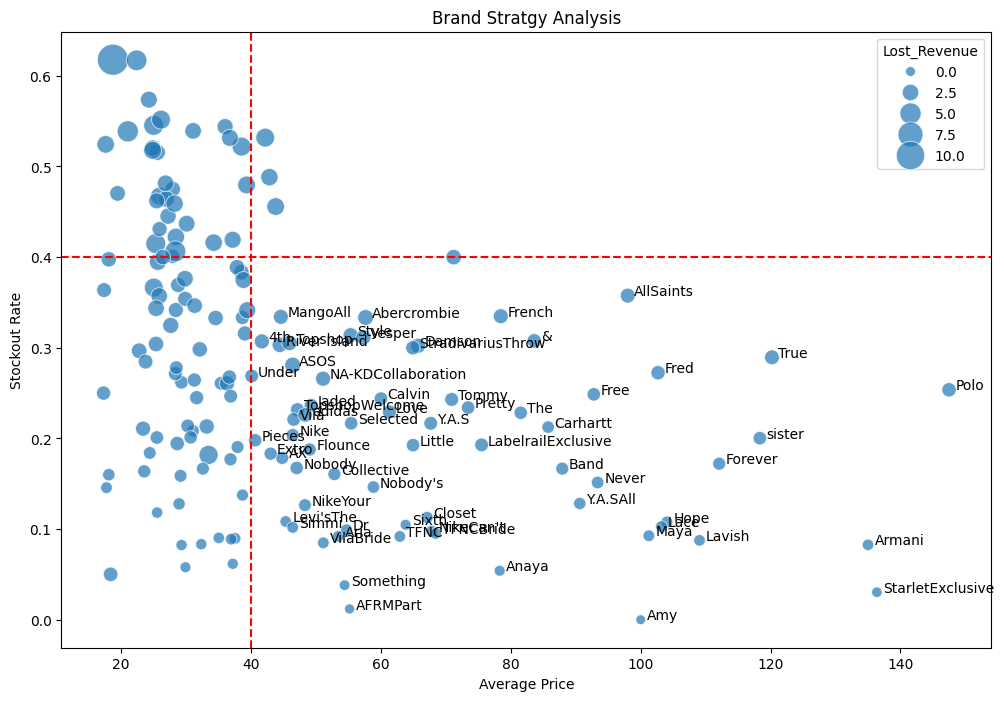

In [17]:
brand_strategy = df_clean.groupby('Brand').agg({
    'price':'mean',
    'Stockout_Rate':'mean',
    'Lost_Revenue':'mean',
    'name':'count'
}).reset_index()

brand_strategy = brand_strategy[brand_strategy['name'] > 10]

plt.figure(figsize = (12,8))
sns.scatterplot(
    data=brand_strategy,
    x='price',
    y='Stockout_Rate',
    size = 'Lost_Revenue',
    sizes = (50,500),
    alpha = 0.7,
    palette = 'viridis'
)

winners = brand_strategy[
    (brand_strategy['price']>40) &
    (brand_strategy['Stockout_Rate'] < 0.4)
]

for i in range(len(winners)):
  plt.text(
      winners.iloc[i]['price']+1,
      winners.iloc[i]['Stockout_Rate'],
      winners.iloc[i]['Brand']

  )

plt.title('Brand Stratgy Analysis')
plt.xlabel('Average Price')
plt.ylabel('Stockout Rate')
plt.axvline(x=40, color='red', linestyle = '--')
plt.axhline(y=0.4, color='red', linestyle = '--')
#axv meaning vertical, h meaning horizontal
plt.show()


In [18]:
#explain the meaning of the results

#Bottom left is low price low demand. They don't often run out of stock and they don't bring in as much revenue
# Top left is high price high demand. They are brands that often run out of stock but also costs a high price.
# It would be best for the business to focus on brands with a high stockout rate, that would be the best way to increase revenue.